# Introduction to Optimization with Python

In [1]:
# Setup header
import matplotlib.pyplot as plt
import numpy as np
from pulp import *
from scipy.optimize import Bounds, minimize, minimize_scalar
from sympy import symbols, diff, solve

## Introduction to Optimization

### Applying an objective function

Here we are doing a plot of the objective function $C(q) = 50 + 5(q - 2)^2$ where the $C(q)$ is the cost in thousands of dollars for printing $q$ thousands of magazines. Eyeballing is sufficient for minimization:

Text(0, 0.5, 'Cost ($ K)')

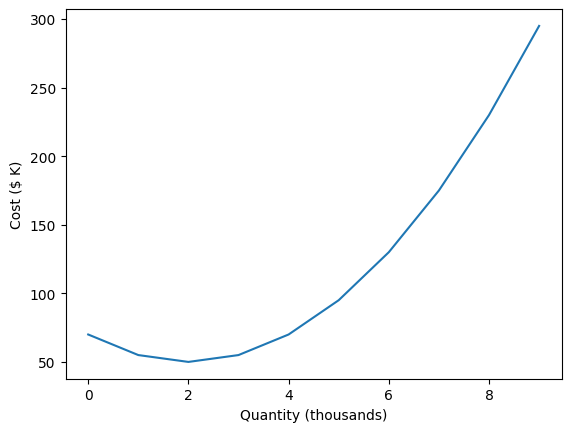

In [2]:
# Create an array of integers from 0 to 10
quantity = np.arange(10)

# Define the cost function
def cost(q): 
  return 50 + 5 * (q - 2)**2

# Plot cost versus quantity
plt.plot(quantity, cost(quantity))
plt.xlabel('Quantity (thousands)')
plt.ylabel('Cost ($ K)')

### Exhaustive search method

I was able to get the source code of the DataCamp function supplied using `??` in the IPython console:

In [3]:
def profit(q): 
    return (10 * q - 25 - q**2) + 11

# Calculate the profit for every quantity
profits = profit(quantity)

# Find the maximum profit
max_profit = max(profits)

# Find the optimal quantity
max_profit_ind = np.argmax(profits)
optimal_quantity = quantity[max_profit_ind]

# Print the results
f'You need to print {optimal_quantity * 1000} magazines to make the maximum profit of ${max_profit * 1000}.'

'You need to print 5000 magazines to make the maximum profit of $11000.'

### Finding the derivative

My first use of SymPy! `solve()` finds the sole root of the derivative:

In [4]:
# Convert q into a symbol
q = symbols('q')
c = 2000 - q**2 + 120 * q

# Find the derivative of the objective function
dc_dq = diff(c)
print(f"The derivative is {dc_dq}.")

# Solve the derivative
q_opt = solve(dc_dq)
f'Optimum quantity: {q_opt}'

The derivative is 120 - 2*q.


'Optimum quantity: [60]'

### Find the second derivative

The exercise wanted me to do `.subs()` on `d2c_dq2` but presumably in the current version of SymPy, because the result is a constant, a `SympifyError` is raised. Not sure what they were going for but apparently because the result is negative the optimum in question is a maximum:

In [5]:
# Find the second derivative
d2c_dq2 = diff(dc_dq)

# Substitute the optimum into the second derivative
# sol = d2c_dq2.subs(q, q_opt)
f'The 2nd derivative at q_opt is: {d2c_dq2}'

'The 2nd derivative at q_opt is: -2'

### Partial derivatives with SymPy

"You are an economist working for an automotive company. Your manager has modeled the production process as a function of the number of machines $K$ and the number of workers $L$ to produce $F(K, L) = -3K^2 + 100K - \frac{1}{2}L^2 + 100L$ cars. This is your multivariate objective function. You'll need to use partial derivatives to optimize this function."

In [6]:
K, L = symbols('K L')
F = -3*K**2 + 100* K - (1/2)*L**2 + 100*L

Ooh nice, automatic $\LaTeX{}$ formatting in Jupyter:

In [7]:
F

-3*K**2 + 100*K - 0.5*L**2 + 100*L

Here's how to find the critical point:

In [8]:
# Derive the partial derivatives
dF_dK = diff(F, K)
dF_dL = diff(F, L)
	
# Solve the equations
crit_points = solve((dF_dK, dF_dL), (K, L))
crit_points

{K: 16.6666666666667, L: 100.000000000000}

From [LibreTexts](https://math.libretexts.org/Bookshelves/Applied_Mathematics/Business_Calculus_with_Excel_(May_and_Bart)/06%3A_Functions_of_Several_Variables/6.03%3A_Critical_Points_and_Extrema):

"To test if a critical point is a maximum, minimum, or saddle point we compute the discriminant of the function."

In [9]:
dF_dK

100 - 6*K

In [10]:
dF_dL

100 - 1.0*L

Only two terms need to be calculated for the discriminant. (The other two are zero.)

In [11]:
dF_dK_dK = diff(dF_dK)
dF_dK_dK

-6

In [12]:
dF_dL_dL = diff(dF_dL)
dF_dL_dL

-1.00000000000000

Based on the information from the book, because $D(a, b) > 0$ and $f_{xx} < 0$ (using the book's terms), the critical point is a **maximum**.

## Unconstrained and Linear Constrained Optimization

### Finding the maxima

"Unconstrained optimization is finding the maxima or minima of a function that does not have any constraints or restrictions on the input variables.

Suppose you are launching a new product in your delicious cookie company and you want to maximize the revenue. The revenue can be modeled with this objective function where $R$ is the revenue generated at price $x$.

$R(x) = -x^2 + 3x - 5$

Solve this maximization problem using SciPy's `minimize_scalar()` which has been loaded for you."

In [13]:
# Define the new objective function
def negated_function(x):
  return -(-(x**2) + 3*x - 5)

# Maximize the negated function
result = minimize_scalar(negated_function)

# Print the result
f'The maximum is {result.x:.2f} in two decimals'

'The maximum is 1.50 in two decimals'

Not very good wording. `result.x` is really the "argmax". The actual maximum:

In [14]:
f'The (actual) maximum is {result.fun:.2f} in two decimals'

'The (actual) maximum is 2.75 in two decimals'

### Multivariate optimization

"Great job maximizing that revenue! You now want to look at minimizing costs.

You'll need to consider two variables for your new cookie product, the sugar ingredient (`a[0]`) and the flour ingredient (`a[1]`). This is a multivariate optimization problem where you want to find the best way to mix these ingredients so that your cookies are delicious but not too expensive!

SciPy's `minimize()` function has been loaded for you and the objective function has been provided."

Same thing applies here with `.x` and `.fun`:

In [15]:
def objective_function(a):
    return (a[0] - 2)**2 + (a[1] - 3)**2 + 3 

# Save your initial guess
x0 = (0, 0)

# Calculate and print the minimum
result = minimize(objective_function, x0)

print(f'The argmin is (x, y) = ({result.x[0]:.2f}, {result.x[1]:.2f}) in two decimals.')
print(f'The minimum is f(x, y) = {result.fun:.2f} in two decimals.')

The argmin is (x, y) = (2.00, 3.00) in two decimals.
The minimum is f(x, y) = 3.00 in two decimals.


### Working with Bounds

Bound-constrained problems have variables that are limited to a range of values.

You're running a coffee shop and need to place an order for two varieties of coffee beans: `b[0]` and `b[1]`. You want to minimize costs. Your supplier only accepts minimum quantity orders of 2 units for each bean, and you can afford a maximum of 100 units per bean.

`minimize` and `Bounds` from `scipy.optimize` have been loaded for you and the objective function is provided.

In [16]:
def objective_function(b):
    return (b[0] - 6)**2 + (b[1] - 8)**2 + 3

# Set the bounds of your problem
bounds = Bounds(2, 100)

x0 = (2, 2)

# Find the minimum
result = minimize(objective_function, x0, bounds=bounds)

print(f'The argmin is (x, y) = ({result.x[0]:.0f}, {result.x[1]:.0f})')
print(f'The minimum is f(x, y) = {result.fun:.0f}')

The argmin is (x, y) = (6, 8)
The minimum is f(x, y) = 3


### Handling hard inequalities

Back in the coffee shop, you want to look at minimizing daily expenses. You have an objective function that calculates your production costs, and a constraint function that tells you the limits of how much coffee you can produce.

Apply SciPy to find the optimal allocation of resources to minimize costs.

In [17]:
def objective_function(b):
    return (b[0] - 5) ** 2 + (b[1] - 3) ** 3

# NOTE: For an inequality-type constraint, the return value must be non-negative
def constraint_function(x):
    return 2*x[0] + 3*x[1] - 6

# Set the constraint variable
constraint = {'type': 'ineq',
              'fun': constraint_function}

x0 = [20, 20]

# Find the minimum
result = minimize(objective_function, x0, constraints=[constraint])

result

 message: Inequality constraints incompatible
 success: False
  status: 4
     fun: -5596424370440672.0
       x: [ 2.665e+05 -1.775e+05]
     nit: 3
     jac: [ 0.000e+00  9.456e+10]
    nfev: 9
    njev: 3

The crucial thing here appears to be `success: False`, along with `message: Inequality constraints incompatible`. The values of keys `fun` and `x` don't really need interpretation I suppose.